In [1]:
# Regresion multiple con Auto MPG (unidades metricas)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

plt.style.use('seaborn-v0_8')


In [2]:
# Cargar dataset Auto MPG

url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data'

column_names = [
    'mpg', 'cylinders', 'displacement', 'horsepower',
    'weight', 'acceleration', 'model_year', 'origin', 'car_name',
]

auto = pd.read_csv(
    url,
    names=column_names,
    na_values='?',
    comment='\t',
    sep=' ',
    skipinitialspace=True,
)

# Nos quedamos con columnas numericas relevantes
auto = auto[['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year']].dropna()
auto.head()


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
0,18.0,8,307.0,130.0,3504.0,12.0,70
1,15.0,8,350.0,165.0,3693.0,11.5,70
2,18.0,8,318.0,150.0,3436.0,11.0,70
3,16.0,8,304.0,150.0,3433.0,12.0,70
4,17.0,8,302.0,140.0,3449.0,10.5,70


In [3]:
# Convertir a unidades metricas: peso (kg) y consumo (L/100 km)

auto['weight_kg'] = auto['weight'] * 0.45359237
auto['consumo_l_100km'] = 235.214583 / auto['mpg']

auto[['mpg', 'consumo_l_100km', 'weight', 'weight_kg']].head()


,mpg,consumo_l_100km,weight,weight_kg
0,18.0,13.067477,3504.0,1589.387664
1,15.0,15.680972,3693.0,1675.116622
2,18.0,13.067477,3436.0,1558.543383
3,16.0,14.700911,3433.0,1557.182606
4,17.0,13.836152,3449.0,1564.440084


In [4]:
# Definir variables para regresion multiple

# Variables predictoras (X): peso, caballos de fuerza y cilindros
X = auto[['weight_kg', 'horsepower', 'cylinders']]
# Variable objetivo (y): consumo en L/100 km
y = auto['consumo_l_100km']

X.head()


,weight_kg,horsepower,cylinders
0,1589.387664,130.0,8
1,1675.116622,165.0,8
2,1558.543383,150.0,8
3,1557.182606,150.0,8
4,1564.440084,140.0,8


In [5]:
# Separar en train y test

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,
)

X_train.shape, X_test.shape


((313, 3), (79, 3))

In [7]:
# Entrenar modelo de regresion multiple

lin_reg_multi = LinearRegression()
lin_reg_multi.fit(X_train, y_train)

coeficientes = pd.Series(lin_reg_multi.coef_, index=X.columns)
intercepto = lin_reg_multi.intercept_

print('Intercepto:', round(intercepto, 3))
print('Coeficientes:')
print(coeficientes.round(6))


Intercepto: -0.751
Coeficientes:
weight_kg     0.004878
horsepower    0.033263
cylinders     0.342169
dtype: float64


In [8]:
# Evaluar el modelo multiple

y_pred = lin_reg_multi.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f'R2  (coeficiente de determinacion): {r2:.4f}')
print(f'MAE (error absoluto medio)       : {mae:.4f} L/100km')


R2  (coeficiente de determinacion): 0.8389
MAE (error absoluto medio)       : 1.1914 L/100km


In [9]:
# Comparar modelo simple vs multiple (opcional)

# Modelo simple solo con peso (por si quieres comparar)
X_simple = auto[['weight_kg']]
y_simple = auto['consumo_l_100km']

Xs_train, Xs_test, ys_train, ys_test = train_test_split(
    X_simple, y_simple, test_size=0.2, random_state=42,
)

lin_reg_simple = LinearRegression()
lin_reg_simple.fit(Xs_train, ys_train)

ys_pred = lin_reg_simple.predict(Xs_test)

r2_simple = r2_score(ys_test, ys_pred)
mae_simple = mean_absolute_error(ys_test, ys_pred)

print('Modelo simple (solo peso):')
print(f'  R2 : {r2_simple:.4f}')
print(f'  MAE: {mae_simple:.4f} L/100km')

print('Modelo multiple (peso, hp, cilindros):')
print(f'  R2 : {r2:.4f}')
print(f'  MAE: {mae:.4f} L/100km')


Modelo simple (solo peso):
  R2 : 0.8282
  MAE: 1.2028 L/100km
Modelo multiple (peso, hp, cilindros):
  R2 : 0.8389
  MAE: 1.1914 L/100km


In [10]:
# Funcion para predecir con el modelo multiple

def predecir_consumo(peso_kg, horsepower, cylinders):
    datos = np.array([[peso_kg, horsepower, cylinders]])
    return lin_reg_multi.predict(datos)[0]

ejemplo = predecir_consumo(1300, 90, 4)
print(f'Ejemplo -> 1300 kg, 90 hp, 4 cilindros: {ejemplo:.2f} L/100km')


Ejemplo -> 1300 kg, 90 hp, 4 cilindros: 9.95 L/100km


d:\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Gráfico 2D fijando hp y cilindros

d:\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


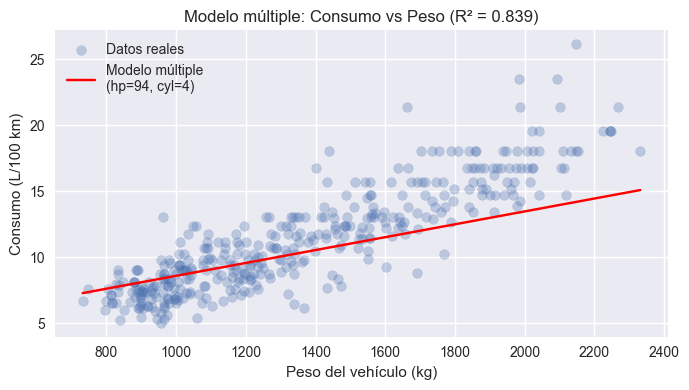

In [11]:
# Celda nueva al final del notebook de regresión múltiple

import numpy as np
import matplotlib.pyplot as plt

# Elegimos valores típicos de hp y cilindros (puedes cambiarlos)
hp_fijo = auto["horsepower"].median()
cil_fijo = auto["cylinders"].mode()[0]

# Rango de pesos
min_peso = auto["weight_kg"].min()
max_peso = auto["weight_kg"].max()

def grafico_modelo_multiple():
    # 1) Datos reales (peso vs consumo)
    plt.figure(figsize=(7, 4))
    plt.scatter(
        auto["weight_kg"],
        auto["consumo_l_100km"],
        alpha=0.3,
        label="Datos reales"
    )

    # 2) Recta de predicciones del modelo múltiple
    pesos_linea = np.linspace(min_peso, max_peso, 100)
    X_linea = np.column_stack([
        pesos_linea,                 # weight_kg
        np.full_like(pesos_linea, hp_fijo),      # horsepower fijo
        np.full_like(pesos_linea, cil_fijo),     # cilindros fijos
    ])
    consumos_linea = lin_reg_multi.predict(X_linea)

    plt.plot(
        pesos_linea,
        consumos_linea,
        color="red",
        label=f"Modelo múltiple\n(hp={hp_fijo:.0f}, cyl={cil_fijo})"
    )

    plt.xlabel("Peso del vehículo (kg)")
    plt.ylabel("Consumo (L/100 km)")
    plt.title(f"Modelo múltiple: Consumo vs Peso (R² = {r2:.3f})")
    plt.legend()
    plt.tight_layout()
    plt.show()

grafico_modelo_multiple()


Versión interactiva con sliders

In [12]:
from ipywidgets import interact, FloatSlider, IntSlider

def grafico_interactivo(peso_kg, horsepower, cylinders):
    consumo_pred = lin_reg_multi.predict(
        np.array([[peso_kg, horsepower, cylinders]])
    )[0]

    plt.figure(figsize=(7, 4))
    plt.scatter(
        auto["weight_kg"],
        auto["consumo_l_100km"],
        alpha=0.3,
        label="Datos reales"
    )

    # Línea para esos hp y cilindros
    pesos_linea = np.linspace(min_peso, max_peso, 100)
    X_linea = np.column_stack([
        pesos_linea,
        np.full_like(pesos_linea, horsepower),
        np.full_like(pesos_linea, cylinders),
    ])
    consumos_linea = lin_reg_multi.predict(X_linea)
    plt.plot(pesos_linea, consumos_linea, color="red", label="Modelo múltiple")

    # Punto de la predicción actual
    plt.scatter([peso_kg], [consumo_pred], color="black", s=80, label="Predicción")

    plt.xlabel("Peso del vehículo (kg)")
    plt.ylabel("Consumo (L/100 km)")
    plt.title(f"Consumo vs Peso (R² = {r2:.3f})")
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(
        f"Peso: {peso_kg:.1f} kg, hp: {horsepower:.0f}, cilindros: {cylinders} "
        f"-> consumo estimado: {consumo_pred:.2f} L/100 km"
    )

interact(
    grafico_interactivo,
    peso_kg=FloatSlider(
        min=min_peso,
        max=max_peso,
        step=50,
        value=(min_peso + max_peso) / 2,
        description="Peso (kg)",
    ),
    horsepower=FloatSlider(
        min=auto["horsepower"].min(),
        max=auto["horsepower"].max(),
        step=5,
        value=hp_fijo,
        description="HP",
    ),
    cylinders=IntSlider(
        options=sorted(auto["cylinders"].unique()),
        value=cil_fijo,
        description="Cilindros",
    ),
)


interactive(children=(FloatSlider(value=1531.5546373050001, description='Peso (kg)', max=2331.4647818000003, m…

<function __main__.grafico_interactivo(peso_kg, horsepower, cylinders)>